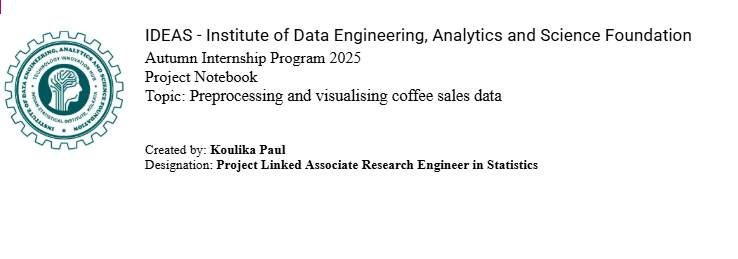

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [53]:
coffee_data=pd.read_csv("Coffee_sales.csv")
coffee_data

,hour_of_day,cash_type,money,coffee_name,Time_of_Day,Weekday,Month_name,Weekdaysort,Monthsort,Date,Time
0,10,card,38.70,Latte,Morning,Fri,Mar,5,3,2024-03-01,10:15:50.520000
1,12,card,38.70,Hot Chocolate,Afternoon,Fri,Mar,5,3,2024-03-01,12:19:22.539000
2,12,card,38.70,Hot Chocolate,Afternoon,Fri,Mar,5,3,2024-03-01,12:20:18.089000
3,13,card,28.90,Americano,Afternoon,Fri,Mar,5,3,2024-03-01,13:46:33.006000
4,13,card,38.70,Latte,Afternoon,Fri,Mar,5,3,2024-03-01,13:48:14.626000
...,...,...,...,...,...,...,...,...,...,...,...
3542,10,card,35.76,Cappuccino,Morning,Sun,Mar,7,3,2025-03-23,10:34:54.894000
3543,14,card,35.76,Cocoa,Afternoon,Sun,Mar,7,3,2025-03-23,14:43:37.362000
3544,14,card,35.76,Cocoa,Afternoon,Sun,Mar,7,3,2025-03-23,14:44:16.864000
3545,15,card,25.96,Americano,Afternoon,Sun,Mar,7,3,2025-03-23,15:47:28.723000


**Q1. Find the number of columns, duplicate columns, and missing values**

In [54]:
num_of_columns=coffee_data.shape[1] #Total number of columns in the coffee sales record
print("Number of columns:", num_of_columns)

duplicate_columns=coffee_data.columns[coffee_data.columns.duplicated()].tolist() #Duplicate values in each column of the record
print("Duplicate columns:", duplicate_columns if duplicate_columns else "No duplicate columns")

missing_colmn_val=coffee_data.isnull().sum() #Missing values in the record
print("Missing values in each column:\n",missing_colmn_val)

Number of columns: 11
Duplicate columns: No duplicate columns
Missing values in each column:
 hour_of_day    0
cash_type      0
money          0
coffee_name    0
Time_of_Day    0
Weekday        0
Month_name     0
Weekdaysort    0
Monthsort      0
Date           0
Time           0
dtype: int64


***Basic statistics of the data***

In [55]:
coffee_data.describe()

,hour_of_day,money,Weekdaysort,Monthsort
count,3547.000000,3547.000000,3547.000000,3547.000000
mean,14.185791,31.645216,3.845785,6.453905
std,4.234010,4.877754,1.971501,3.500754
min,6.000000,18.120000,1.000000,1.000000
25%,10.000000,27.920000,2.000000,3.000000
50%,14.000000,32.820000,4.000000,7.000000
75%,18.000000,35.760000,6.000000,10.000000
max,22.000000,38.700000,7.000000,12.000000


In [56]:
coffee_data.dtypes

hour_of_day      int64
cash_type       object
money          float64
coffee_name     object
Time_of_Day     object
Weekday         object
Month_name      object
Weekdaysort      int64
Monthsort        int64
Date            object
Time            object
dtype: object

In [57]:
coffee_data['Date']= pd.to_datetime(coffee_data['Date']) ## converting the object datatype to datetime
coffee_data['Month']=coffee_data['Date'].dt.month
coffee_data['Year']=(coffee_data['Date'].dt.year).astype('int')

***Average money for each year***

In [58]:
grouped_data=coffee_data.groupby('Year')['money'].agg(np.mean)
grouped_data

C:\Users\RIMJHIM\AppData\Local\Temp\ipykernel_6948\3058338727.py:1: FutureWarning: The provided callable <function mean at 0x0000024AFE723CE0> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  grouped_data=coffee_data.groupby('Year')['money'].agg(np.mean)


Year
2024    31.737634
2025    31.390011
Name: money, dtype: float64

**Q2. Find the datatype of grouped_data**

In [59]:
grouped_data = coffee_data.groupby("coffee_name")["money"].sum().reset_index()
print(grouped_data.head())
print("Datatype of grouped data:", type(grouped_data))

           coffee_name     money
0            Americano  14650.26
1  Americano with Milk  24751.12
2           Cappuccino  17439.14
3                Cocoa   8521.16
4              Cortado   7384.86
Datatype of grouped data: <class 'pandas.core.frame.DataFrame'>


**Q3. Find the maximum money for each month**

In [60]:
max_money = coffee_data.groupby("Month_name")["money"].max() # Maximum amount recorded for each month
print("Maximum money earned each month:", max_money)

Maximum money earned each month: Month_name
Apr    38.70
Aug    32.82
Dec    35.76
Feb    35.76
Jan    35.76
Jul    37.72
Jun    37.72
Mar    38.70
May    37.72
Nov    35.76
Oct    35.76
Sep    35.76
Name: money, dtype: float64


***Distribution of money over months***

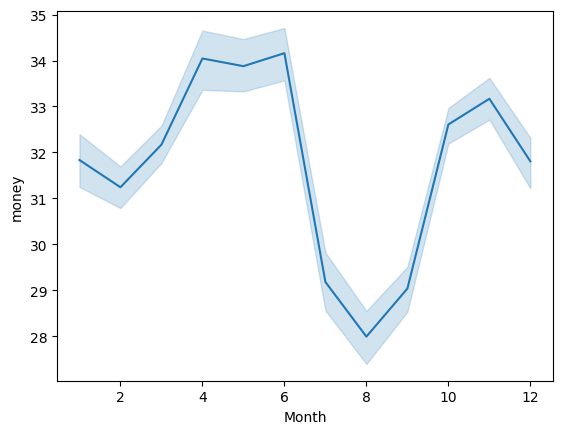

In [61]:
sns.lineplot(x=coffee_data['Month'],y='money',data=coffee_data)
plt.show()

***The density of money over years***

<Axes: xlabel='Year', ylabel='money'>

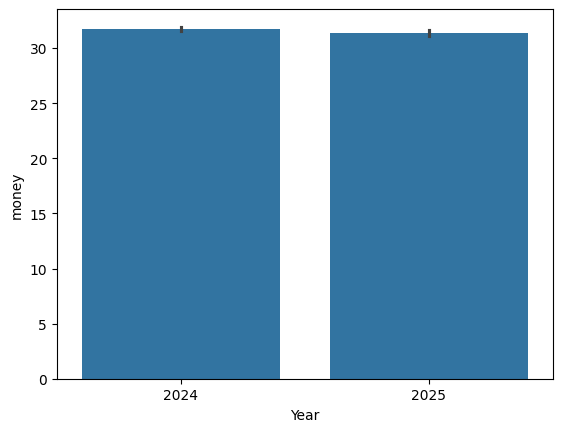

In [62]:
sns.barplot(data= coffee_data,x='Year',y= coffee_data['money'])


**Q4. Find the distribution of money over coffee names**


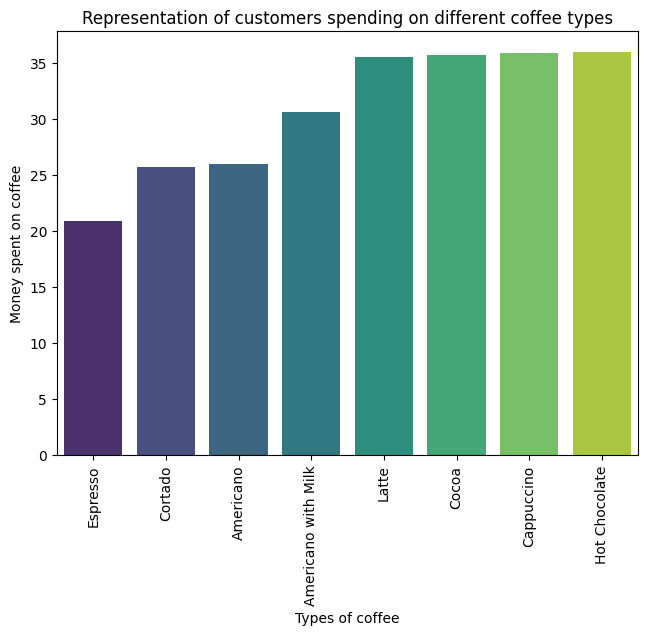

In [63]:
avg_money_per_coffee = coffee_data.groupby("coffee_name")["money"].mean().sort_values()

#Plot bar chart
plt.figure(figsize=(7.5,5.5))
sns.barplot(x=avg_money_per_coffee.index, y=avg_money_per_coffee.values, hue=avg_money_per_coffee.index, palette="viridis")
plt.xticks(rotation=90)
plt.ylabel("Money spent on coffee")
plt.xlabel("Types of coffee")
plt.title("Representation of customers spending on different coffee types")
plt.show()

***Times of the Day the dataset holds***

In [64]:
coffee_data['Time_of_Day'].value_counts()

Time_of_Day
Afternoon    1205
Morning      1181
Night        1161
Name: count, dtype: int64

**Q5. How many types of coffees are present in the dataset?**

In [65]:
num_coffee=coffee_data["coffee_name"].nunique() #Number of coffee types
print("Number of coffee types:", num_coffee)

coffee_types=coffee_data["coffee_name"].unique() #Types of coffee sold by the cafe
print("Coffee's sold here:\n", coffee_types)

Number of coffee types: 8
Coffee's sold here:
 ['Latte' 'Hot Chocolate' 'Americano' 'Americano with Milk' 'Cocoa'
 'Cortado' 'Espresso' 'Cappuccino']


***Max money from coffee_name***

In [66]:
coffee_data.groupby('coffee_name')['money'].max()

coffee_name
Americano              28.9
Americano with Milk    33.8
Cappuccino             38.7
Cocoa                  38.7
Cortado                28.9
Espresso               24.0
Hot Chocolate          38.7
Latte                  38.7
Name: money, dtype: float64

**Q6. Find the average money made at what time of the day.**

In [67]:
avg_money_spent = coffee_data.groupby("Time_of_Day")["money"].mean() #Coffee spending sorted by time
print("Average spending on coffee:", avg_money_spent, "\nNight time on an average records more coffee sales!")

Average spending on coffee: Time_of_Day
Afternoon    31.643187
Morning      30.422693
Night        32.890904
Name: money, dtype: float64 
Night time on an average records more coffee sales!


***Generate 100 synthetic data rows***

**Q7. Insert synthetic data into the given data set and analyse as above.**

In [68]:
import numpy as np
df = pd.read_csv("Coffee_sales.csv")
# Number of synthetic rows to create
n_synth = 100

# Get unique values from existing data for categorical fields
coffee_types = df["coffee_name"].unique()
cash_types = df["cash_type"].unique()
time_of_day = df["Time_of_Day"].unique()
weekdays = df["Weekday"].unique()
months = df["Month_name"].unique()

# Generate synthetic data
np.random.seed(42)
synthetic_data = {
    "hour_of_day": np.random.randint(6, 22, n_synth),
    "cash_type": np.random.choice(cash_types, n_synth),
    "money": np.round(np.random.uniform(20, 60, n_synth), 2),
    "coffee_name": np.random.choice(coffee_types, n_synth),
    "Time_of_Day": np.random.choice(time_of_day, n_synth),
    "Weekday": np.random.choice(weekdays, n_synth),
    "Month_name": np.random.choice(months, n_synth),
    "Weekdaysort": np.random.randint(1, 8, n_synth),
    "Monthsort": np.random.randint(1, 13, n_synth),
    "Date": pd.date_range(start="2024-07-01", periods=n_synth, freq="D").strftime("%Y-%m-%d"),
    "Time": pd.date_range(start="2024-07-01 08:00:00", periods=n_synth, freq="H").strftime("%H:%M:%S"),
}

df_synth = pd.DataFrame(synthetic_data)

# Append
df_combined = pd.concat([df, df_synth], ignore_index=True)

#total sales before vs after adding synthetic data
original_sales = df["money"].sum()
combined_sales = df_combined["money"].sum()
original_count = len(df)
combined_count = len(df_combined)
(original_count, combined_count, original_sales, combined_sales)
print(df_combined)


      hour_of_day cash_type  money          coffee_name Time_of_Day Weekday  \
0              10      card  38.70                Latte     Morning     Fri   
1              12      card  38.70        Hot Chocolate   Afternoon     Fri   
2              12      card  38.70        Hot Chocolate   Afternoon     Fri   
3              13      card  28.90            Americano   Afternoon     Fri   
4              13      card  38.70                Latte   Afternoon     Fri   
...           ...       ...    ...                  ...         ...     ...   
3642           11      card  21.48  Americano with Milk   Afternoon     Thu   
3643           15      card  44.38           Cappuccino       Night     Thu   
3644            9      card  40.11              Cortado     Morning     Tue   
3645           11      card  22.06           Cappuccino   Afternoon     Wed   
3646           18      card  31.15                Latte       Night     Tue   

     Month_name  Weekdaysort  Monthsort        Date

C:\Users\RIMJHIM\AppData\Local\Temp\ipykernel_6948\3835049487.py:26: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  "Time": pd.date_range(start="2024-07-01 08:00:00", periods=n_synth, freq="H").strftime("%H:%M:%S"),


Analysis fo the new data added to Coffee sales data.

In [69]:
# 1. Number of columns, duplicates, missing values
print("Number of columns:", df_combined.shape[1])
print("\nDuplicate columns:", df_combined.columns[df_combined.columns.duplicated()].tolist())
print("\nMissing values:\n", df_combined.isnull().sum())
print("\n")

# 2. Datatype of grouped data
grouped_data = df_combined.groupby("coffee_name")["money"].sum()
print(grouped_data.head())
print("Datatype of grouped data:", type(grouped_data))
print("\n")

# 3. Maximum earning in a month
max_money = df_combined.groupby("Month_name")["money"].max()
print("Maximum money earned each month:\n", max_money)
print("\n")

Number of columns: 11

Duplicate columns: []

Missing values:
 hour_of_day    0
cash_type      0
money          0
coffee_name    0
Time_of_Day    0
Weekday        0
Month_name     0
Weekdaysort    0
Monthsort      0
Date           0
Time           0
dtype: int64


coffee_name
Americano              15290.06
Americano with Milk    25302.50
Cappuccino             18137.20
Cocoa                   8746.38
Cortado                 7784.15
Name: money, dtype: float64
Datatype of grouped data: <class 'pandas.core.series.Series'>


Maximum money earned each month:
 Month_name
Apr    54.86
Aug    48.27
Dec    58.87
Feb    57.58
Jan    50.43
Jul    58.50
Jun    57.72
Mar    59.48
May    52.15
Nov    52.72
Oct    52.30
Sep    58.78
Name: money, dtype: float64




Distribution of earnings upon different coffee names

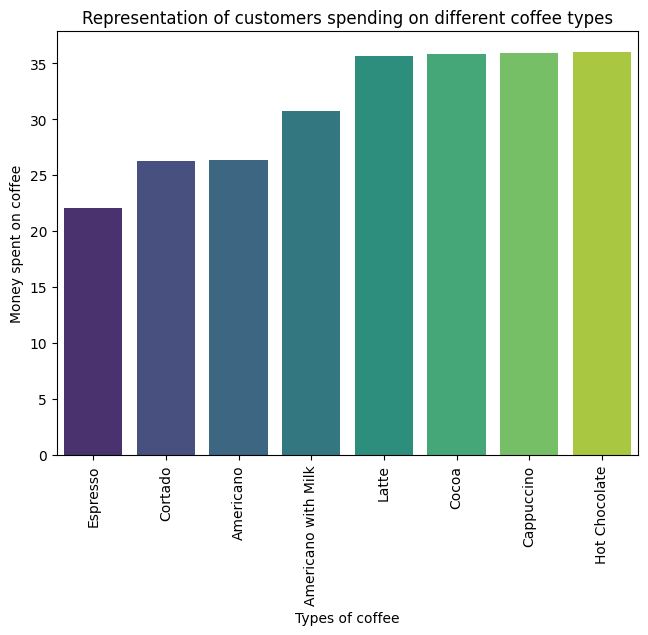

In [70]:
avg_money_per_coffee = df_combined.groupby("coffee_name")["money"].mean().sort_values()
plt.figure(figsize=(7.5,5.5))
sns.barplot(x=avg_money_per_coffee.index, y=avg_money_per_coffee.values, hue=avg_money_per_coffee.index, palette="viridis")
plt.xticks(rotation=90)
plt.ylabel("Money spent on coffee")
plt.xlabel("Types of coffee")
plt.title("Representation of customers spending on different coffee types")
plt.show()
print("\n")

In [71]:
# 5. Coffee types provided
num_coffee=df_combined["coffee_name"].nunique()
print("Number of coffee types:", num_coffee)
coffee_types=df_combined["coffee_name"].unique()
print("Coffee's sold here:\n", coffee_types)
print("\n")
# 6. Average earning against time of the day
avg_money_spent = df_combined.groupby("Time_of_Day")["money"].mean() #Coffee spending sorted by time
print("Average spending on coffee:", avg_money_spent)
print("\n")

Number of coffee types: 8
Coffee's sold here:
 ['Latte' 'Hot Chocolate' 'Americano' 'Americano with Milk' 'Cocoa'
 'Cortado' 'Espresso' 'Cappuccino']


Average spending on coffee: Time_of_Day
Afternoon    31.875073
Morning      30.643092
Night        33.084769
Name: money, dtype: float64


